In [138]:
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs 

la dimension de x (100, 2)
la dimension de y (100, 1)


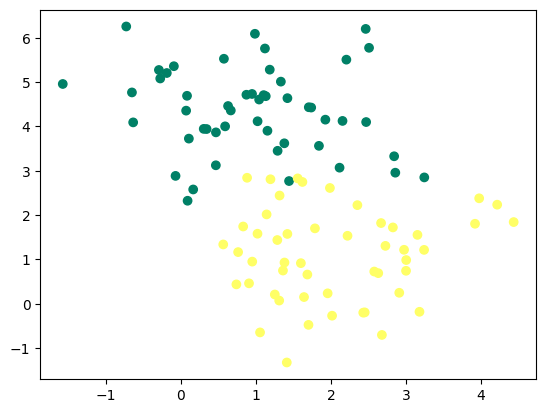

In [139]:
x,y= make_blobs(n_samples=100 , n_features=2 , centers=2 , random_state=0)
y=y.reshape((y.shape[0], 1))

print("la dimension de x",x.shape)
print("la dimension de y", y.shape)

plt.scatter(x[:,0],x[:,1] , c=y , cmap='summer')
plt.show()

# fonction d'Itialisation 

In [140]:
def initialisation(x):
    w=np.random.randn(x.shape[1],1)
    b=np.random.randn(1)
    return (w,b)
    

In [141]:
w,b= initialisation(x)
b

array([-0.63774142])

# Algorithme : modèle de neurone artificielle

In [142]:
def model(x,w,b):
    z=x.dot(w)+b
    A=1/(1+ np.exp(z))
    return  A
A=model(x,w,b)
A.shape

(100, 1)

# Fonction d'évaluation 

In [143]:
def log_loss(A,y): # fontion coût
    return 1/len(y)*np.sum(-y*np.log(A)-(1-y)*np.log(1-A))

log_loss(A,y)

np.float64(0.8702757522442249)

# Gradients 


In [144]:
def gradients(A,x,y):
    dw=1/len(y)* np.dot(x.T, A-y)
    db=1/len(y)*np.sum(A-y)
    return (dw,db)

gradients(A,x,y)


(array([[-0.79799705],
        [-0.26793746]]),
 np.float64(-0.32914385288422593))

In [145]:
w.shape

(2, 1)

In [146]:
# fonction de modification 
def update(dw, db,w,b,learning_rate):
    w=w-learning_rate*dw
    b=b-learning_rate*db
    return(w,b)

In [147]:
def predict(x,w,b):
    A=model(x,w,b)
    return A>=0.5


# rassembler notre algorithme

In [148]:
from sklearn.metrics import accuracy_score

In [149]:
def artificial_neurone(x,y,learning_rate=0.1, n_iter=100):
    #initialisation de w,b
    w,b=initialisation(x)
    loss=[]
    for i in range(n_iter):
        A=model(x,w,b)
        loss.append(log_loss(A,y))
        dw,db=gradients(A,x,y)
        w,b=update(dw,db,w,b, learning_rate)

    y_pred=predict(x,w,b)
    print(accuracy_score(y, y_pred))

    plt.plot(loss)
    plt.show()


0.47


C:\Users\samya.taqi\AppData\Local\Temp\ipykernel_9748\3206101227.py:2: RuntimeWarning: divide by zero encountered in log
  return 1/len(y)*np.sum(-y*np.log(A)-(1-y)*np.log(1-A))
C:\Users\samya.taqi\AppData\Local\Temp\ipykernel_9748\3206101227.py:2: RuntimeWarning: invalid value encountered in multiply
  return 1/len(y)*np.sum(-y*np.log(A)-(1-y)*np.log(1-A))


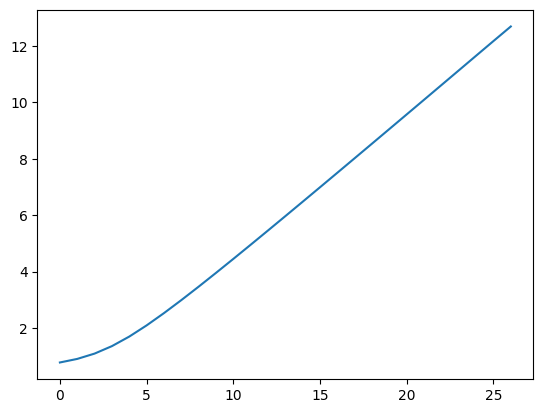

In [150]:
artificial_neurone(x,y)